# Slow farmer Kolmogorov equations
This is complex enough that it deserves its own notebook

In [6]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [7]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [8]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [9]:
R = 0.00888
K = 0.00772

## setting up system

In [10]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [14]:
#s matrix elements

def s_ijkl(i, j, k, l, N, A):

    if i == k and j == l:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    elif i == k-1 and j == l:
        return growthRate(k-1, N, A)
    elif i == k+1 and j == l:
        return eatRate(k+1, N, A)*l/N
    elif i == k+1 and j == l-1:
        return eatRate(k+1, N, A)*(N-l+1)/N
    else:
        return 0

In [32]:
def sMatrix(N, A):
    s_matrix = np.zeros(((N+1)*(A+1), (N+1)*(A+1)))
    for m in range((N+1)*(A+1)):
        for n in range((N+1)*(A+1)):
            #n will be i and j
            #m will be k and l
            #since j increases every time i passes A in the q vector, we need to mod by A+1
            i = m%(A+1)
            j = int(m/(A+1))
            k = n%(A+1)
            l = int(n/(A+1))
            s_matrix[m,n] = s_ijkl(i, j, k, l, N, A)
    return s_matrix

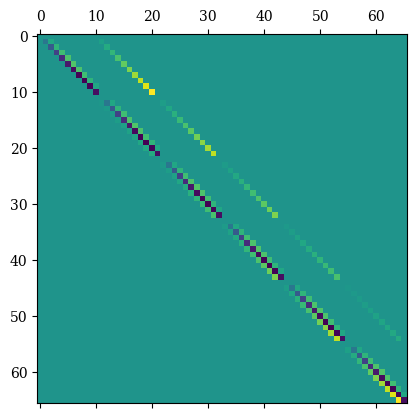

In [33]:
f, ax = plt.subplots()

ax.matshow(sMatrix(5, 10))

## setting up simulation

In [37]:
def simulate(N, A, stoptime):

    s_matrix = sMatrix(N, A)

    q0 = np.zeros((N+1)*(A+1))
    #begin pasture with Ng=A and Nw=0
    #meaning q_A,0 = 1
    #which appears at position A in the vector
    q0[A]=1

    def sys(t, y):
        return np.matmul(y, s_matrix)

    st = time.time()

    s = sp.integrate.solve_ivp(sys, (0, stoptime), q0)

    print("finished in {0} seconds".format(time.time()-st))
    return s

In [79]:
sol = simulate(16, 40, 3600)

finished in 0.12121248245239258 seconds


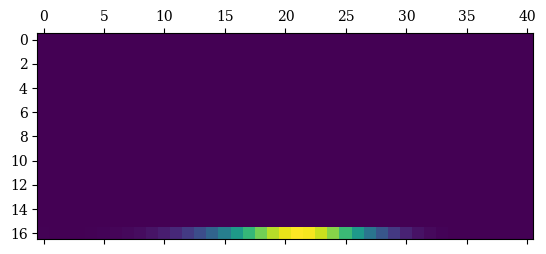

In [92]:
f, ax = plt.subplots()

ax.matshow(np.reshape(sol["y"][:,300], (16+1, 40+1)))